In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import functools
from numpy import median

In [36]:
sns.catplot = functools.partial(sns.catplot, aspect=2.5)
sns.relplot = functools.partial(sns.relplot, aspect=2.5)
sns.lmplot  = functools.partial(sns.lmplot, aspect=2.5)
sns.displot = functools.partial(sns.displot, aspect=2.5)
sns.boxplot = functools.partial(sns.boxplot, aspect=2.5)

In [37]:
survey_data = pd.read_csv('young-people-survey-responses.csv')

student_data = pd.read_csv('student-alcohol-consumption.csv')

Gráficos de recuento

En este ejercicio, volveremos a explorar nuestro conjunto de datos que contiene las respuestas a una encuesta enviada a los jóvenes. Podríamos sospechar que los jóvenes pasan mucho tiempo en Internet, pero ¿cuánto declaran utilizar Internet al día? Utilicemos un gráfico de recuento para desglosar el número de respuestas de la encuesta en cada categoría y luego exploremos si cambia en función de la edad.

Como recordatorio, para crear un gráfico de recuento, utilizaremos la función catplot() y especificaremos el nombre de la variable categórica a contar (x=____), el DataFrame de pandas a utilizar (data=____), y el tipo de gráfico (kind="count").

Seaborn se ha importado como sns y matplotlib.pyplot se ha importado como plt.

Utiliza sns.catplot() para crear un gráfico de recuento utilizando el DataFrame survey_data con "Internet usage" en el eje x.

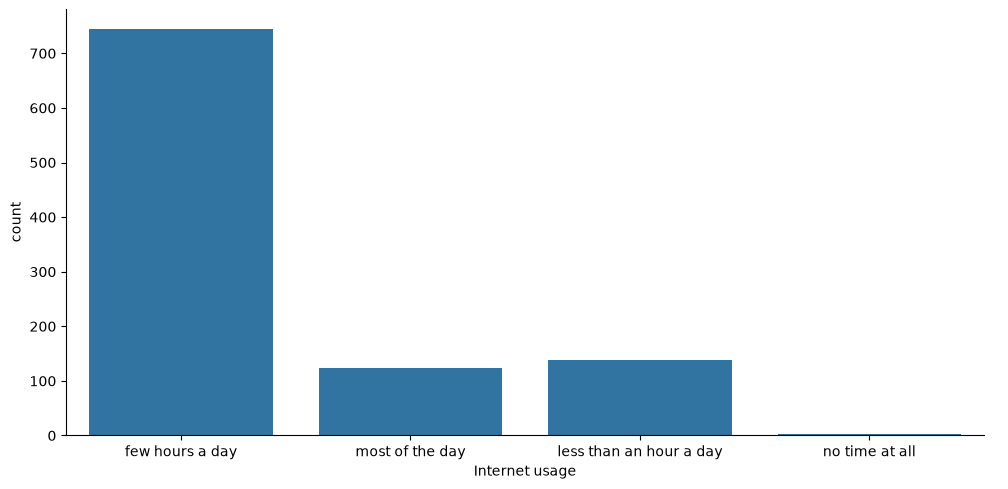

In [38]:
sns.catplot(x='Internet usage', kind='count', data=survey_data, height=5, aspect=2)
plt.show()

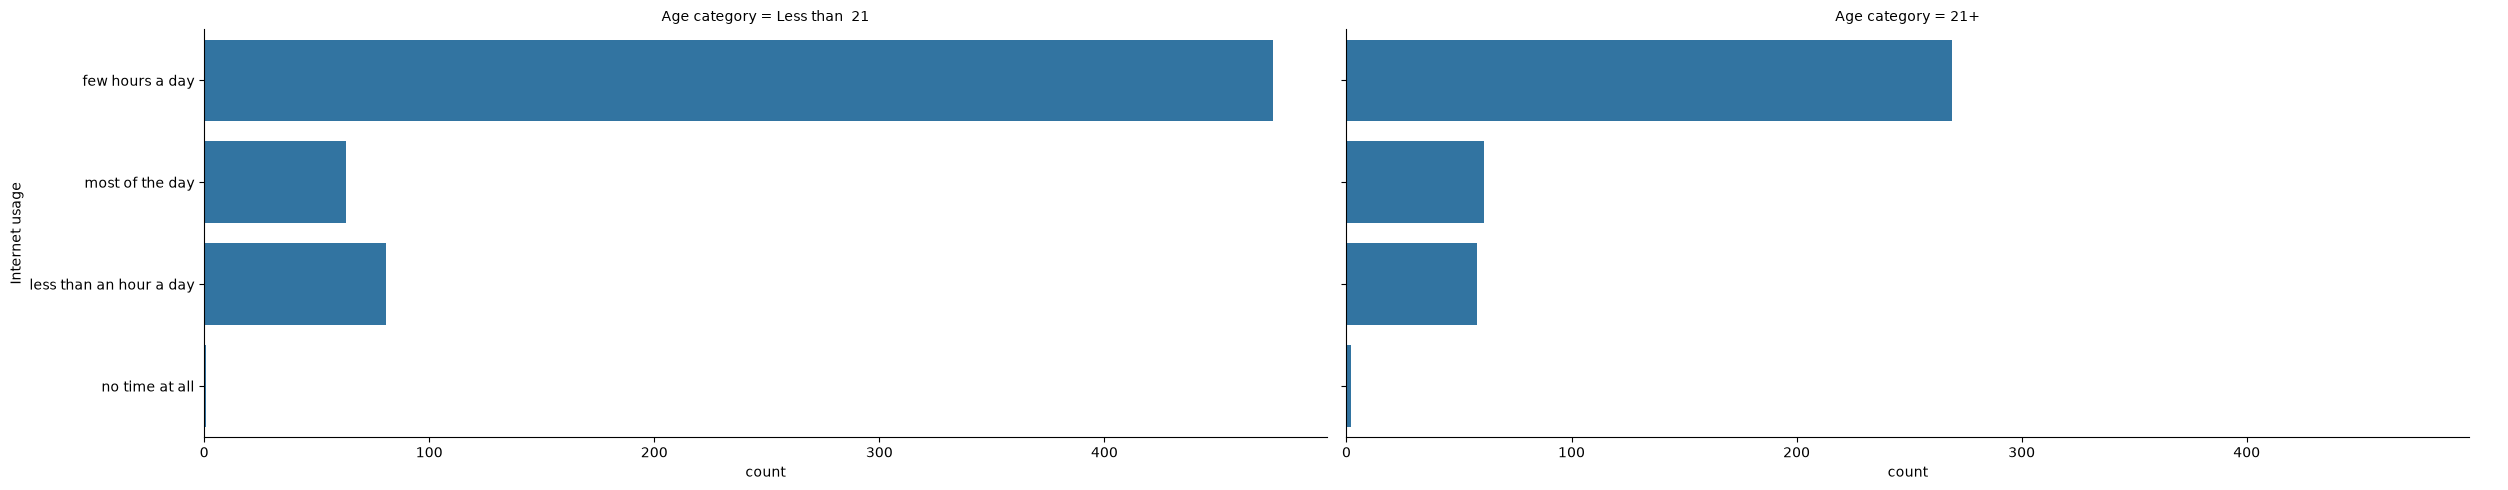

In [39]:
# agregar nueva columna a survey_data con categorías de edad menos de 21, 21+
survey_data['Age category'] = np.where(survey_data['Age'] < 21, 'Less than  21', '21+')

sns.catplot(y='Internet usage', kind='count', data=survey_data, col='Age category')

plt.show()

Diagramas de barras con porcentajes

Sigamos explorando las respuestas a una encuesta enviada a los jóvenes. La variable "Interested in Math" es True si la persona declaró estar interesada o muy interesada en las matemáticas, y False en caso contrario. ¿Qué porcentaje de jóvenes afirma estar interesado en las matemáticas, y varía esto en función del género? Utilicemos un diagrama de barras para averiguarlo.

Como recordatorio, crearemos un gráfico de barras utilizando la función catplot(), proporcionando el nombre de la variable categórica a poner en el eje x (x=____), el nombre de la variable cuantitativa a resumir en el eje y (y=____), el DataFrame de pandas a utilizar (data=____), y el tipo de gráfico categórico (kind="bar").

Seaborn se ha importado como sns y matplotlib.pyplot se ha importado como plt.
Utiliza el DataFrame survey_data y sns.catplot() para crear un gráfico de barras con "Gender" en el eje x y "Interested in Math" en el eje y.

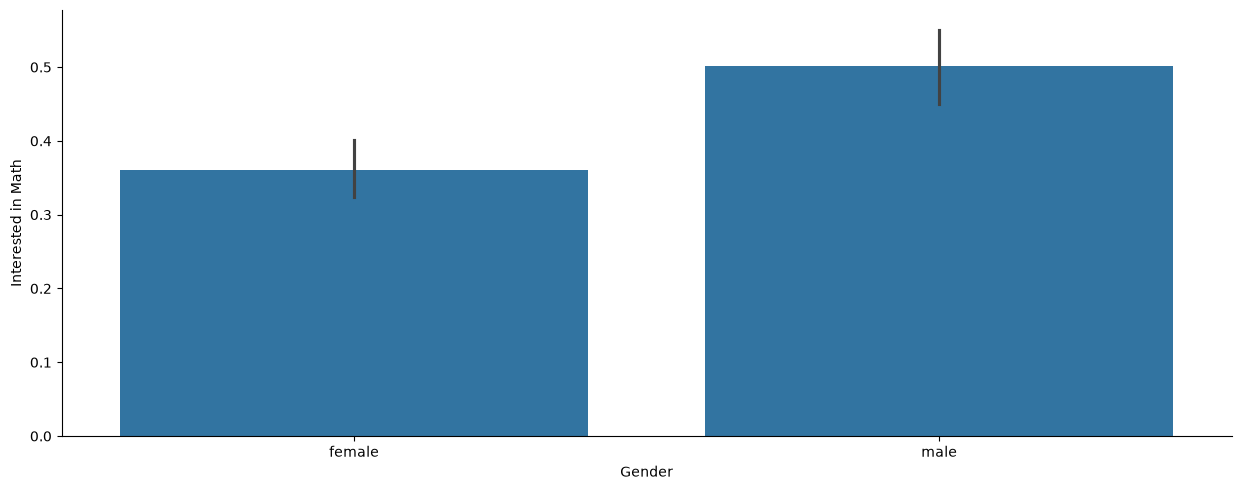

In [40]:
survey_data['Interested in Math'] = np.where(survey_data['Mathematics'] < 3, False, True)

sns.catplot(x='Gender', y='Interested in Math', kind='bar', data=survey_data)
plt.show()

Personalizar gráficos de barras

En este ejercicio, exploraremos datos de alumnos de secundaria. La variable "study_time" registra el tiempo de estudio semanal declarado por cada estudiante como una de las siguientes categorías: "<2 hours", "2 to 5 hours", "5 to 10 hours", o ">10 hours". ¿Los alumnos que declaran estudiar más tienden a obtener mejores notas finales? Comparemos la nota media final entre los alumnos de cada categoría mediante un diagrama de barras.

Seaborn se ha importado como sns y matplotlib.pyplot se ha importado como plt.

Utiliza sns.catplot() para crear un gráfico de barras con "study_time" en el eje x y la calificación final ("G3") en el eje y, utilizando el DataFrame student_data.

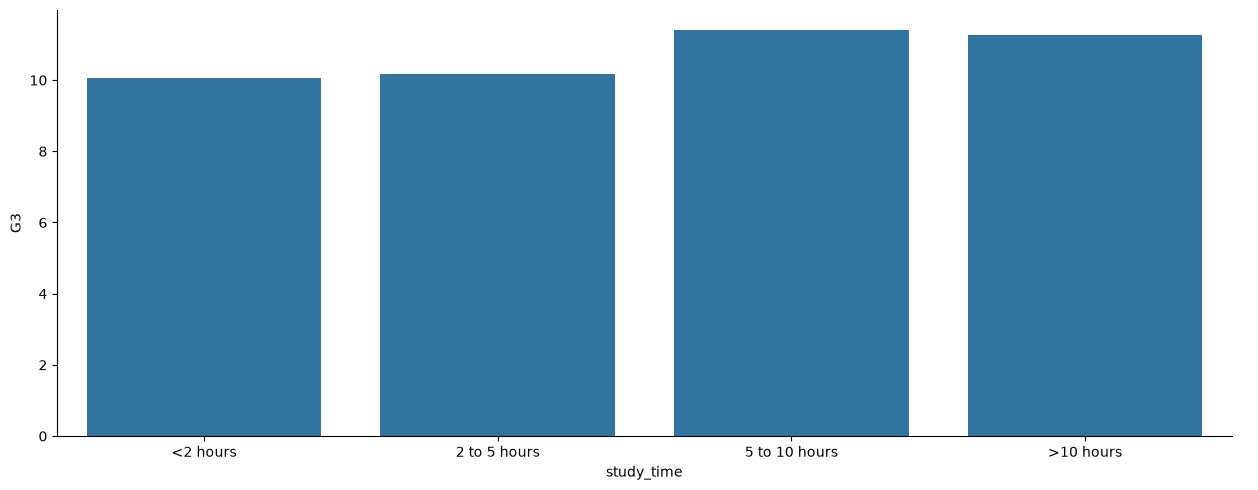

In [41]:
category_order = ["<2 hours", 
                  "2 to 5 hours", 
                  "5 to 10 hours", 
                  ">10 hours"]
sns.catplot(x='study_time', y='G3', kind='bar', data=student_data, order=category_order, errorbar=None)
plt.show()

Crea e interpreta un diagrama de cajas

Sigamos utilizando el conjunto de datos student_data. En un ejercicio anterior, exploramos la relación entre el estudio y la nota final utilizando un diagrama de barras para comparar la nota final media ("G3") entre los estudiantes de diferentes categorías de "study_time".

En este ejercicio, intentaremos utilizar un diagrama de cajas para ver esta relación. Como recordatorio, para crear un gráfico de caja tendrás que utilizar la función catplot() y especificar el nombre de la variable categórica a poner en el eje x (x=____), el nombre de la variable cuantitativa a resumir en el eje y (y=____), el DataFrame de pandas a utilizar (data=____), y el tipo de gráfico (kind="box").

Ya hemos importado matplotlib.pyplot como plt y seaborn como sns.

Utiliza sns.catplot() y el DataFrame student_data para crear un gráfico de caja con "study_time" en el eje x y "G3" en el eje y. Establece el orden de las categorías en study_time_order.

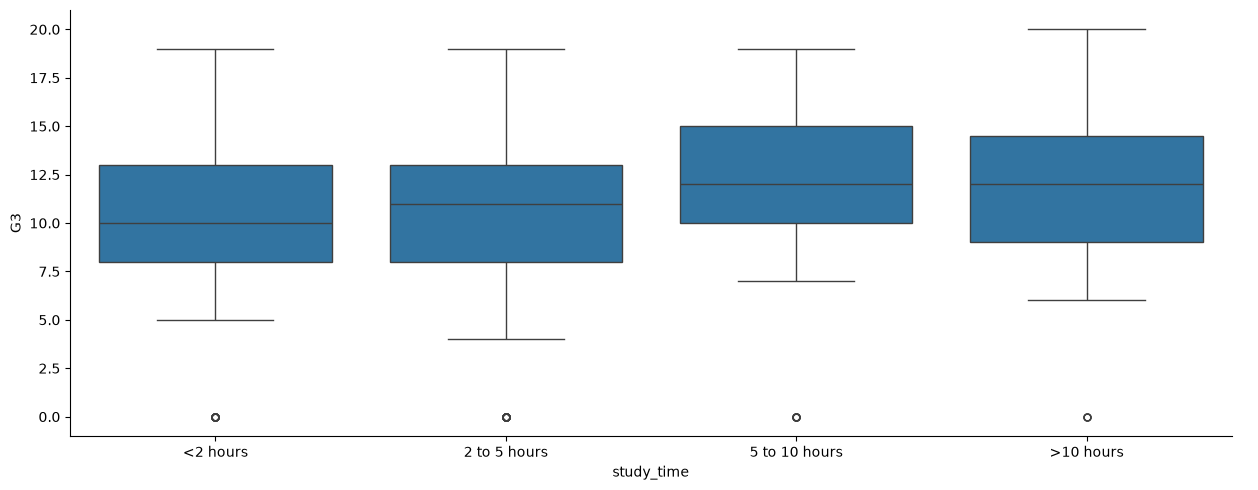

In [42]:
study_time_order = ["<2 hours", "2 to 5 hours", 
                    "5 to 10 hours", ">10 hours"]

sns.catplot(x='study_time', y='G3', kind='box', data=student_data, order=study_time_order)
plt.show()

Omitir valores atípicos

Ahora vamos a utilizar el conjunto de datos student_data para comparar la distribución de las calificaciones finales ("G3") entre los estudiantes que tienen acceso a Internet en casa y los que no. Para ello, utilizaremos la variable "internet", que es un indicador binario (sí/no) de si el alumno tiene acceso a Internet en casa.

Dado que Internet puede ser menos accesible en las zonas rurales, añadiremos subgrupos en función de dónde viva el alumno. Para ello, podemos utilizar la variable "location", que es un indicador de si un estudiante vive en una localidad urbana ("Urban") o rural ("Rural").

Seaborn ya se ha importado como sns y matplotlib.pyplot se ha importado como plt. Como recordatorio, puedes omitir los valores atípicos en los gráficos de caja estableciendo showfliers=False.

Utiliza sns.catplot() para crear un gráfico de caja con el DataFrame student_data, poniendo "internet" en el eje x y "G3" en el eje y.
Añade subgrupos para que cada diagrama de caja se coloree en función de "location".
No muestres los valores atípicos.

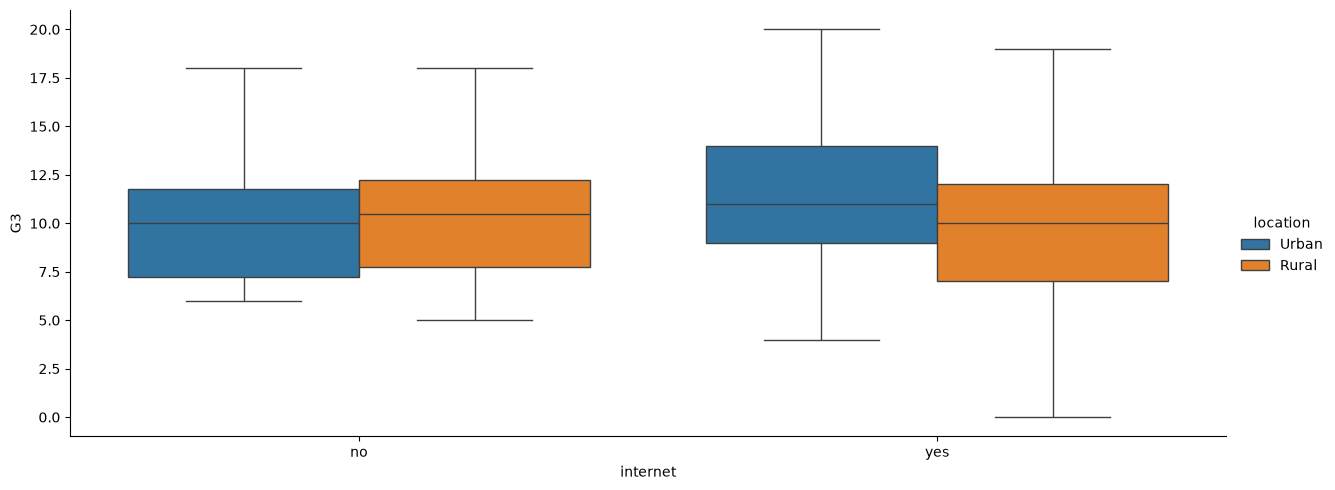

In [43]:
sns.catplot(x='internet', y='G3', kind='box', hue='location', showfliers=False, data=student_data)
plt.show()

Ajustar los bigotes

En la lección vimos que hay múltiples formas de definir los bigotes en un diagrama de caja. En esta serie de ejercicios, seguiremos utilizando el conjunto de datos student_data para comparar la distribución de las calificaciones finales ("G3") entre los estudiantes que mantienen una relación romántica y los que no. Utilizaremos la variable "romantic", que es un indicador sí/no de si el alumno tiene una relación romántica.

Vamos a crear un diagrama de cajas para ver esta relación y probar distintas formas de definir los bigotes.

Ya hemos importado Seaborn como sns y matplotlib.pyplot como plt.

Ajusta el código para que los bigotes del gráfico de caja se extiendan hasta 0,5 * IQR. Recordatorio: el IQR es el rango intercuartílico.

Cambia el código para que los bigotes se extiendan hasta los percentiles 5 y 95.

Cambia el código para que los bigotes se extiendan hasta los valores mínimo y máximo

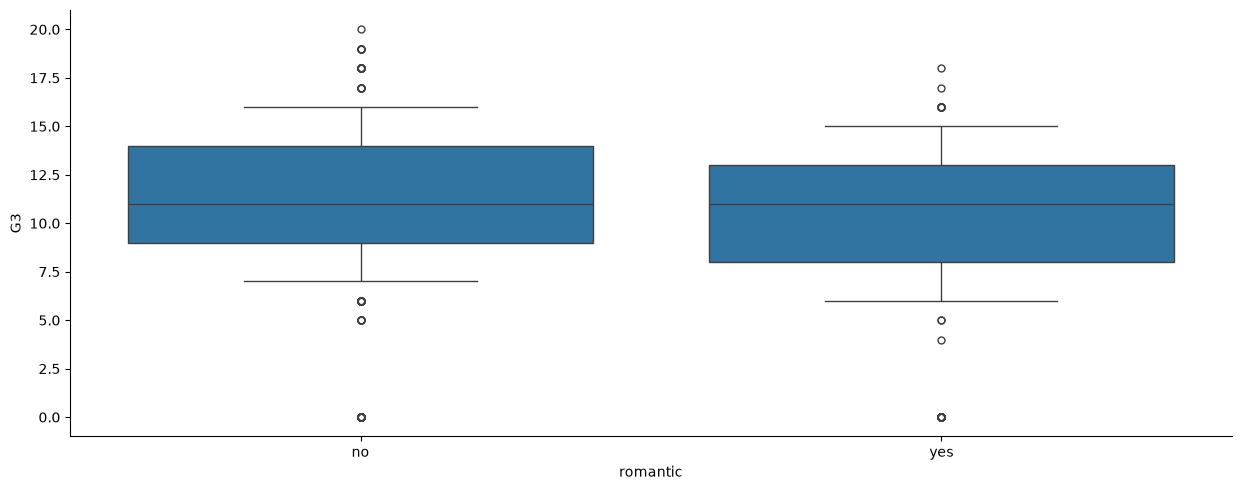

In [44]:
# Set the whiskers to 0.5 * IQR
sns.catplot(x="romantic", y="G3",
            data=student_data,
            kind="box", whis=0.5)
# Show plot
plt.show()



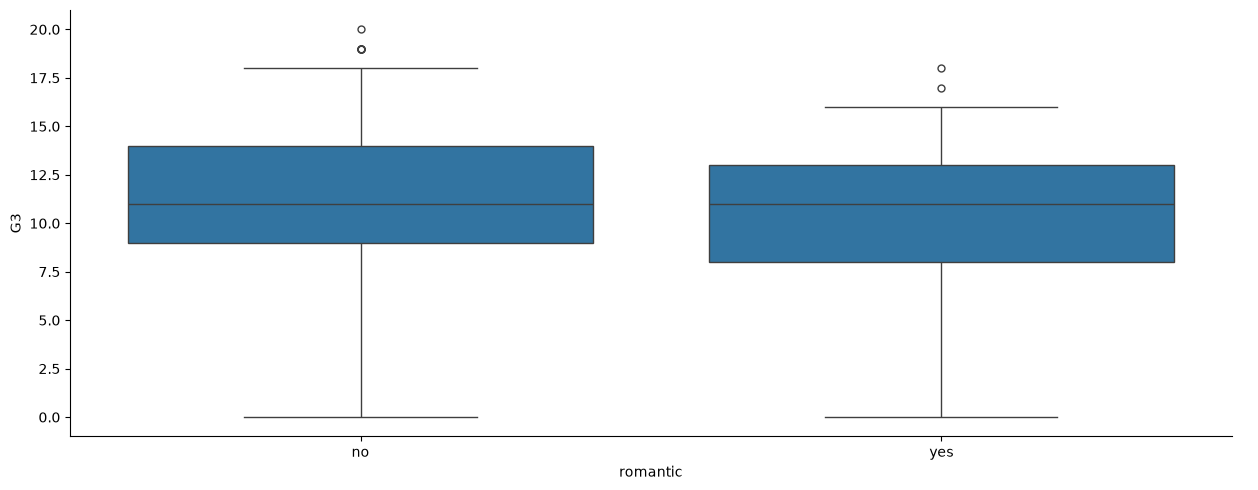

In [45]:
sns.catplot(x="romantic", y="G3",
            data=student_data,
            kind="box", whis=[5,95])
plt.show()

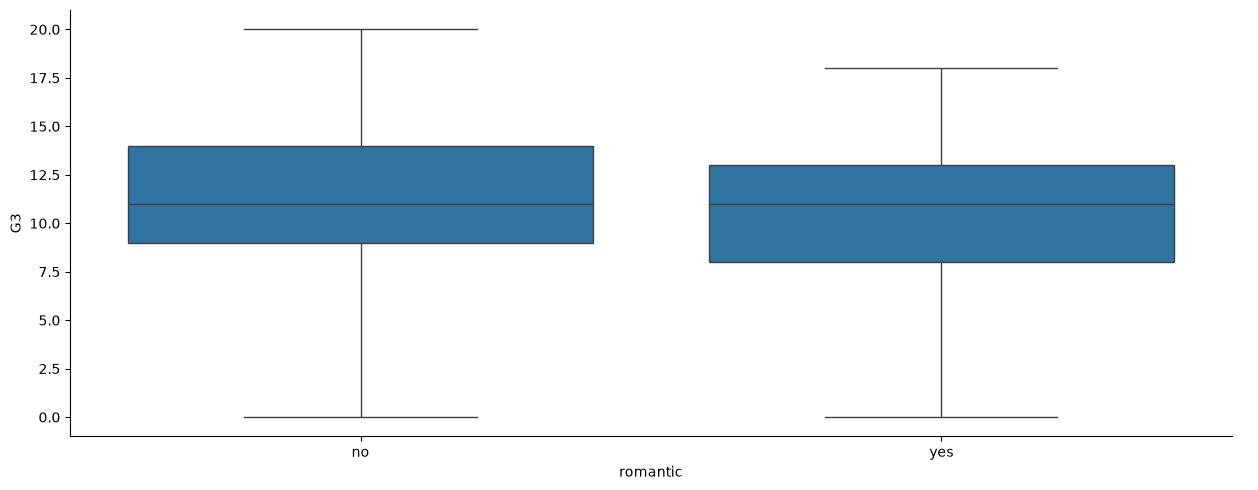

In [46]:
sns.catplot(x="romantic", y="G3",
            data=student_data,
            kind="box", whis=[0,100])
plt.show()

Personalizar los gráficos de puntos

Sigamos examinando datos de alumnos de secundaria, esta vez utilizando un gráfico de puntos para responder a la pregunta: ¿influye la calidad de la relación familiar del alumno en el número de faltas que tiene en la escuela? Aquí utilizaremos la variable "famrel", que describe la calidad de la relación familiar de un alumno de 1 (muy mala) a 5 (muy buena).

Como recordatorio, para crear un gráfico de puntos, utiliza la función catplot() y especifica el nombre de la variable categórica a poner en el eje x (x=____), el nombre de la variable cuantitativa a resumir en el eje y (y=____), el DataFrame de pandas a utilizar (data=____), y el tipo de gráfico categórico (kind="point").

Ya hemos importado Seaborn como sns y matplotlib.pyplot como plt.


    Utiliza sns.catplot() y el DataFrame student_data para crear un gráfico de puntos con "famrel" en el eje x y el número de ausencias ("absences") en el eje y.



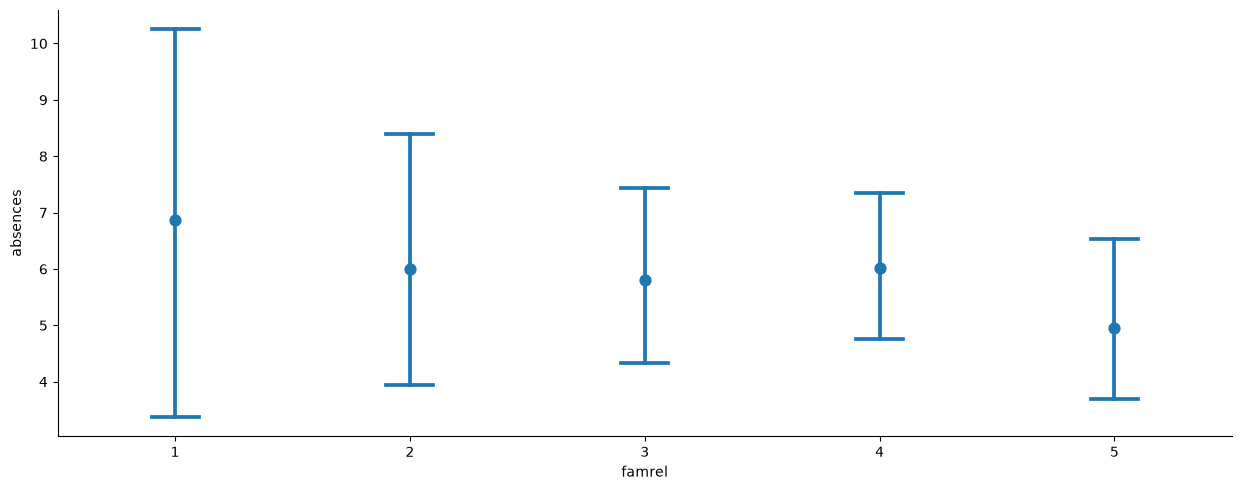

In [47]:
sns.catplot(x='famrel', y='absences', kind='point', data=student_data, capsize=.2, linestyle='none')
plt.show()

Gráficos de puntos con subgrupos

Sigamos explorando el conjunto de datos de los alumnos de secundaria. Esta vez, formularemos la pregunta: ¿estar en una relación romántica está asociado a una mayor o menor asistencia a la escuela? ¿Y difiere esta asociación en función de la escuela a la que asisten los alumnos? Averigüémoslo mediante un gráfico de puntos.

Ya hemos importado Seaborn como sns y matplotlib.pyplot como plt.

Utiliza sns.catplot() y el DataFrame student_data para crear un gráfico de puntos con el estado de la relación ("romantic") en el eje x y el número de ausencias ("absences") en el eje y. Colorea los puntos según la escuela a la que asistan ("school").

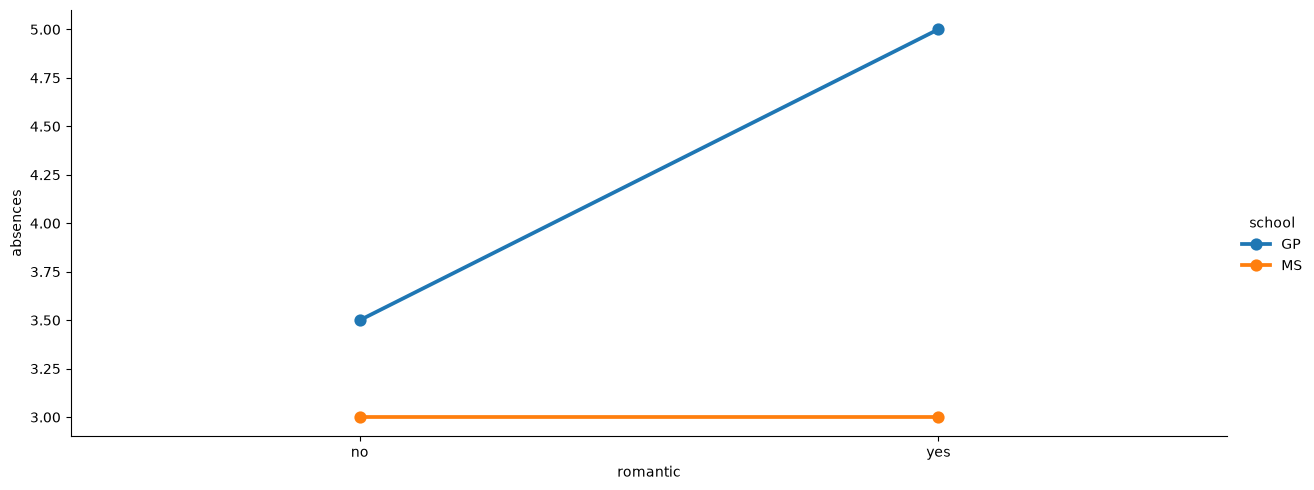

In [48]:
sns.catplot(x='romantic', y='absences', kind='point', data=student_data, hue='school', errorbar=None, estimator=median)
plt.show()